# Experiment 5: Parameter Sensitivity Analysis

**Drug Modeled:** Gefitinib

**Condition Tested:** Sensitivity of the spatial proliferation response P(x) to
selected model parameters.

**Research Question:** Which model parameters most strongly control the predicted spatial
proliferation response to heterogeneous gefitinib exposure?

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters

# Spatial domain
L = 0.2
nx = 200
x = np.linspace(0, L, nx)
dx = x[1] - x[0]

# Solver tolerances
rtol = 1e-9
atol = 1e-12

# Validated diffusion model
D1 = 5e-7
D2 = 1e-7
D3 = 5e-7

boundary_1 = 0.05
boundary_2 = 0.12

C_source = 1.0

T_diffusion = 3600
nt = 30000
dt = T_diffusion / nt

# Load validated exp04b outputs
G = np.load("saved_parameters/exp04b_G.npy")
T_steady = np.load("saved_parameters/exp04b_T_steady.npy")

# Initial state vector
y0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

# Parameter dictionary
params_baseline = {
    "EGF" : 1.0,
    "IC_50" : 0.3,
    "n" : 1.0,
    "k_EGF" : 1.0,
    "k_EGFR_off" : 0.5,
    "k_G" : 0.5,
    "k_RAS" : 1.0,
    "k_RAS_off" : 0.5,
    "k_RAF" : 1.0,
    "k_RAF_off" : 0.5,
    "k_MEK" : 1.0,
    "k_MEK_off" : 0.5,
    "k_ERK" : 1.0,
    "k_ERK_off" : 0.5,
    "k_T" : 1.0,
    "k_deg" : 0.5,
    "k_P" : 1.0,
    "k_loss" : 0.5,
}

In [35]:
# ODE Signaling Function
def pathway(t, y, params, G_x):
    # External factors
    EGF = params["EGF"]
    G = G_x
    IC_50 = params["IC_50"]
    n = params["n"]

    # Extract activated protein and Cyclin D/Proliferation rates from array y
    EGFR_star, RAS_star, RAF_star, MEK_star, ERK_star, CycD, P = y

    # Total protein concentrations
    EGFR_tot = 1.0
    RAS_tot = 1.0
    RAF_tot = 1.0
    MEK_tot = 1.0
    ERK_tot = 1.0

    # Rate constants (normalized currently)
    k_EGF = params["k_EGF"]
    k_EGFR_off = params["k_EGFR_off"]
    k_G = params["k_G"]

    k_RAS = params["k_RAS"]
    k_RAS_off = params["k_RAS_off"]

    k_RAF = params["k_RAF"]
    k_RAF_off = params["k_RAF_off"]

    k_MEK = params["k_MEK"]
    k_MEK_off = params["k_MEK_off"]

    k_ERK = params["k_ERK"]
    k_ERK_off = params["k_ERK_off"]

    k_T = params["k_T"]
    k_deg = params["k_deg"]

    k_P = params["k_P"]
    k_loss = params["k_loss"]

    # Calculating derivatives
    EGFR_gefit = 1 / (1 + (G / IC_50) ** n)
    EGFR_act = k_EGF * EGF * (EGFR_tot - EGFR_star) * EGFR_gefit
    EGFR_dect = k_EGFR_off * EGFR_star

    dEGFR = EGFR_act - EGFR_dect

    RAS_act = k_RAS * EGFR_star * (RAS_tot - RAS_star)
    RAS_dect = k_RAS_off * RAS_star

    dRAS = RAS_act - RAS_dect

    RAF_act = k_RAF * RAS_star * (RAF_tot - RAF_star)
    RAF_dect = k_RAF_off * RAF_star

    dRAF = RAF_act - RAF_dect

    MEK_act = k_MEK * RAF_star * (MEK_tot - MEK_star)
    MEK_dect = k_MEK_off * MEK_star

    dMEK = MEK_act - MEK_dect

    ERK_act = k_ERK * MEK_star * (ERK_tot - ERK_star)
    ERK_dect = k_ERK_off * ERK_star

    dERK = ERK_act - ERK_dect

    CycD_act = k_T * ERK_star
    CycD_dect = k_deg * CycD

    dCycD = CycD_act - CycD_dect

    P_act = k_P * CycD
    P_dect = k_loss * P

    dP = P_act - P_dect

    return [dEGFR, dRAS, dRAF, 
                dMEK, dERK, dCycD, dP]

In [36]:
# Building baseline solutions array
solutions_baseline = np.zeros((7, nx))

for i in range(nx):
    G_local = G[i]

    sol = solve_ivp(
        pathway,
        [0, T_steady],
        y0,
        args=(params_baseline, G_local),
        rtol=rtol,
        atol=atol
    )

    solutions_baseline[:, i] = sol.y[:, -1]

## Baseline Validation

Before performing sensitivity analysis, confirm that the baseline
reproduces the validated exp04b behavior.

In [37]:
# Test 1 : Monotonicity
print("Conducting Test 1 : Monotonicity...")

names = [
    "EGFR*", "RAS*", "RAF*", "MEK*",
    "ERK*", "CycD", "P"
]

for j, name in enumerate(names):

    diff = np.diff(solutions_baseline[j])

    print(
        name,
        "reversals:",
        np.sum(diff < 0)
    )

# Test 2 : Steady-state Residual
print("Conducting Test 2 : Steady-state Residual...")

max_rates = np.zeros(nx)

for i in range(nx):

    dydt = pathway(
        T_steady,
        solutions_baseline[:, i],
        params_baseline,
        G[i]
    )

    max_rates[i] = np.max(np.abs(dydt))

print(
    "Maximum absolute final derivative:",
    np.max(max_rates)
)

Conducting Test 1 : Monotonicity...
EGFR* reversals: 0
RAS* reversals: 0
RAF* reversals: 0
MEK* reversals: 0
ERK* reversals: 0
CycD reversals: 0
P reversals: 0
Conducting Test 2 : Steady-state Residual...
Maximum absolute final derivative: 2.6001223396576734e-09


## Sensitivity Metric

To quantify how strongly each model parameter controls the predicted
spatial heterogeneity in proliferation, we define the spatial
proliferation response as,

$$[
R_P = \frac{P_{\max}-P_{\min}}{P_{\min}}
]$$

where $P_{\max}$ and $P_{\min}$ are the maximum and minimum
steady-state proliferation values across the tissue.

For each parameter $p_{0}$, the model will be evaluated at a lower
perturbed value $p_{-}$ and an upper perturbed value $p_{+}$, while
all other parameters are held at their validated baseline values.

The corresponding spatial proliferation responses are
$R_{P,-}$ and $R_{P,+}$.

A normalized finite-difference sensitivity coefficient is then
calculated as,

$$[
S_p =
\frac{
(R_{P,+}-R_{P,-})/R_{P,0}
}{
(p_+-p_-)/p_{0}
}
]$$

This measures the relative change in spatial proliferation
heterogeneity produced by a relative change in the parameter.

Equivalently, this approximates the logarithmic sensitivity,

$$[
S_p \approx
\frac{\partial \ln R_P}{\partial \ln p}
]$$

The magnitude $S_p$ will be used to rank parameters by influence
on the spatial proliferation response.

- ($|S_p| > 1$): response changes proportionally more than the parameter
- ($|S_p| \approx 1$): response changes approximately proportionally
- ($|S_p| < 1$): response changes proportionally less than the parameter

The sign of $S_p$ indicates whether increasing the parameter tends
to increase ($S_p > 0$) or decrease ($S_p < 0$) spatial proliferation
heterogeneity.

Each parameter will be analyzed independently using the same validated
exp04b baseline model.

## Sensitivity Parameters

Three model components will be tested: effective drug transport,
drug potency, and the steepness of the drug-response relationship.

### Diffusion Multiplier

The validated exp04b model contains three layer-specific diffusion
coefficients:

$$
D_1 = 5 * 10^{-7},

D_2 = 1 * 10^{-7},

D_3 = 5 * 10^{-7}
$$

Rather than varying these coefficients independently, a dimensionless
diffusion multiplier $(\alpha_D)$ will be used:

$$
D_{i'} = \alpha_D D_i
$$

for $(i=1,2,3)$.

The baseline value is therefore

$$
\alpha_D = 1
$$

which reproduces the validated exp04b diffusion model.

This approach changes the overall effective rate of gefitinib
transport while preserving the validated relative differences in
diffusivity between tissue layers.

The diffusion multiplier will therefore be varied independently of
$(IC_{50})$ and $(n)$.

In [38]:
# Provisional sensitivity ranges
# These ranges are exploratory and will be updated
# when literature-supported parameter ranges are established.

sensitivity_parameters = {
    "D_multiplier": np.logspace(
        np.log10(0.2),
        np.log10(2.0),
        10
    ),
    "IC_50": np.linspace(0.15, 0.60, 10),
    "n": np.linspace(0.5, 2.0, 10)
}

In [52]:
# Diffusion profile generation
# Used for sensitivity analysis of diffusion coefficient (D_multiplier)
dx = x[1] - x[0]
print("dx =", dx)
print("Expected dx =", 0.2 / 199)

print("D1:", D1)
print("D2:", D2)
print("D3:", D3)

print("T_diffusion:", T_diffusion)

print("nt:", nt)
print("dt:", dt)

def generate_G(D_multiplier):
    # Scale validated diffusion coefficients
    D1_current = D1 * D_multiplier
    D2_current = D2 * D_multiplier
    D3_current = D3 * D_multiplier

    # Build spatial diffusitivity profile
    D_current = np.full(nx, D1_current)
    D_current[x >= boundary_1] = D2_current
    D_current[x >= boundary_2] = D3_current

    # Initial concentration
    C = np.zeros(nx)
    C[0] = C_source

    # Diffusion simulation
    for t in range(nt):
        C_new = C.copy()

        for i in range(1, nx - 1):
            D_left = (D_current[i] + D_current[i - 1]) / 2
            D_right = (D_current[i] + D_current[i + 1]) / 2

            J_left = -D_left * (C[i] - C[i - 1]) / dx
            J_right = -D_right * (C[i + 1] - C[i]) / dx

            C_new[i] = C[i] + (dt / dx) * (J_left - J_right)

        C = C_new

        # Constant source boundary
        C[0] = C_source

    return C

def generate_G_original():

    D = np.full(nx, D1)

    D[x >= boundary_1] = D2

    D[x >= boundary_2] = D3

    C = np.zeros(nx)

    C[0] = C_source

    for t in range(nt):

        C_new = C.copy()

        for i in range(1, nx - 1):

            D_left = (D[i] + D[i-1]) / 2

            D_right = (D[i] + D[i+1]) / 2

            J_left = -D_left * (C[i] - C[i-1]) / dx

            J_right = -D_right * (C[i+1] - C[i]) / dx

            C_new[i] = C[i] + (dt / dx) * (J_left - J_right)

        C = C_new

        C[0] = C_source

    return C

G_original_reproduced = generate_G_original()

print(

    "Difference between reproduced exp04b and saved G:",

    np.max(np.abs(G_original_reproduced - G))

)

dx = 0.0010050251256281408
Expected dx = 0.0010050251256281408
D1: 5e-07
D2: 1e-07
D3: 5e-07
T_diffusion: 3600
nt: 30000
dt: 0.12
Difference between reproduced exp04b and saved G: 0.21015801406025825


In [40]:
# Central ODE simulation function

def run_spatial_model(params, G_profile):
    solutions = np.zeros((7, len(x)))

    for i in range(len(x)):
        G_local = G_profile[i]

        sol = solve_ivp(
            pathway,
            [0, T_steady],
            y0,
            args=(params, G_local),
            rtol=rtol,
            atol=atol
        )

        solutions[:, i] = sol.y[:, -1]

    return solutions

In [41]:
# Baseline Response

solutions_test = run_spatial_model(params_baseline, G)
P_baseline = solutions_test[6]

CV_P_baseline = np.std(P_baseline) / np.mean(P_baseline)

np.save(
    "saved_parameters/exp05_CV_P_baseline.npy",
    CV_P_baseline
)


## I. IC50 Parameter Sweep

This section shall examine the effect of the $IC_{50}$ parameter on the spatial proliferation response $P(x)$. 

**Definition:** The concentration of an inhibitor required to reduce a specified biological/biochemical activity by 50% under defined experimental conditions. In this model, the inhibitior is gefitinib, and the biological activity is EGFR activation.

In [42]:
# Solving IC50 responses
IC50_values = sensitivity_parameters["IC_50"]
IC50_responses = []

for value in IC50_values:

    # Update parameter dictionary
    params = params_baseline.copy()
    params["IC_50"] = value

    # Run signaling/proliferation model
    solutions = run_spatial_model(
        params,
        G
    )

    # Extract proliferation
    P_1 = solutions[6]

    # Calculate spatial proliferation heterogeneity
    CV_P1 = np.std(P_1) / np.mean(P_1)

    IC50_responses.append(CV_P1)

IC50_responses = np.array(IC50_responses)

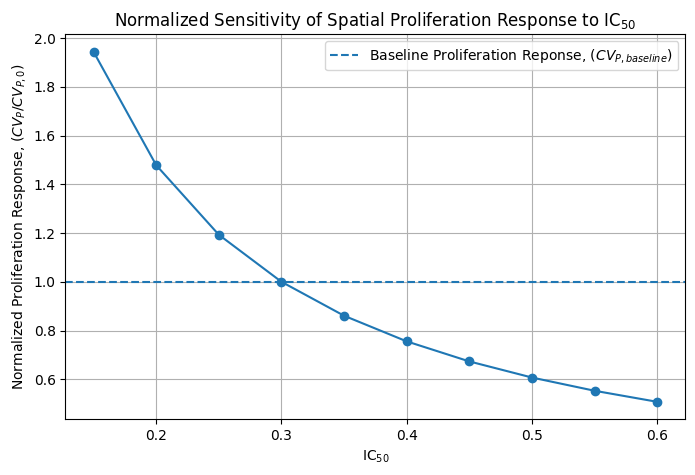

In [43]:
# Plot normalized responses (normalized to R_P_baseline)
IC50_responses_norm = IC50_responses / CV_P_baseline

plt.figure(figsize=(8, 5))

plt.plot(IC50_values, IC50_responses_norm, marker="o")

plt.axhline(1.0, linestyle="--", label="Baseline Proliferation Reponse, (${CV}_{P, baseline}$)")

plt.xlabel(r"$\mathrm{IC}_{50}$")
plt.ylabel(r"Normalized Proliferation Response, (${CV}_P/{CV}_{P,0}$)")
plt.title(r"Normalized Sensitivity of Spatial Proliferation Response to $\mathrm{IC}_{50}$")
plt.grid(True)

plt.legend()
plt.savefig("figures/exp05_IC50_sweep")
plt.show()

## II. Hill Coefficient Parameter Sweep

This section shall examine the effect of the Hill coefficient ($n$) parameter on the spatial proliferation response $P(x)$. 

**Definition:** Characterizes the steepness of the dose–response relationship, with larger values producing a more switch-like response and smaller values producing a more gradual response.

In [44]:
# Solving Hill responses
hill_values = sensitivity_parameters["n"]
hill_responses = []

for value in hill_values:

    # Update dictionary values
    params = params_baseline.copy()
    params["n"] = value

    # Run signaling/proliferation model
    solutions = run_spatial_model(
        params,
        G
    )

    # Extract proliferation
    P_2 = solutions[6]

    # Calculate spatial proliferation response
    CV_P2 = np.std(P_2) / np.mean(P_2)

    hill_responses.append(CV_P2)

hill_responses = np.array(hill_responses)

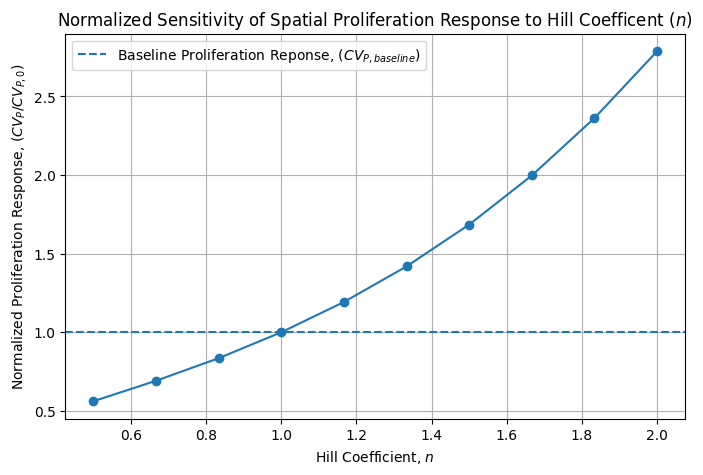

In [45]:
# Plot normalized responses (normalized to R_P_baseline)
hill_responses_norm = hill_responses / CV_P_baseline

plt.figure(figsize=(8, 5))

plt.plot(hill_values, hill_responses_norm, marker="o")

plt.axhline(1.0, linestyle="--", label="Baseline Proliferation Reponse, (${CV}_{P, baseline}$)")

plt.xlabel(r"Hill Coefficient, $n$")
plt.ylabel(r"Normalized Proliferation Response, (${CV}_P/{CV}_{P,0}$)")
plt.title(r"Normalized Sensitivity of Spatial Proliferation Response to Hill Coefficent ($n$)")
plt.grid(True)

plt.legend()
plt.savefig("figures/exp05_hill_sweep")
plt.show()

## III. Diffusion Coefficent Parameter Sweep

This section shall examine the effect of the diffusion coefficient ($D$) parameter on the spatial proliferation response $P(x)$. 

**Definition:** Quantifies the rate at which a substance diffuses through a medium in response to a concentration gradient. Larger diffusion coefficients correspond to faster spatial transport.

In [46]:
# Solving diffusion coefficient responses
D_multiplier_values = sensitivity_parameters["D_multiplier"]
D_responses = []

for D_multiplier in D_multiplier_values:

    # Generate new spatial gefitinib profile
    G_current = generate_G(D_multiplier=D_multiplier)

    # Run signaling/proliferation model
    solutions = run_spatial_model(
        params_baseline,
        G_current
    )

    # Extract proliferation
    P_3 = solutions[6]

    # Calculate spatial proliferation response
    CV_P3 = np.std(P_3) / np.mean(P_3)

    D_responses.append(CV_P3)

D_responses = np.array(D_responses)


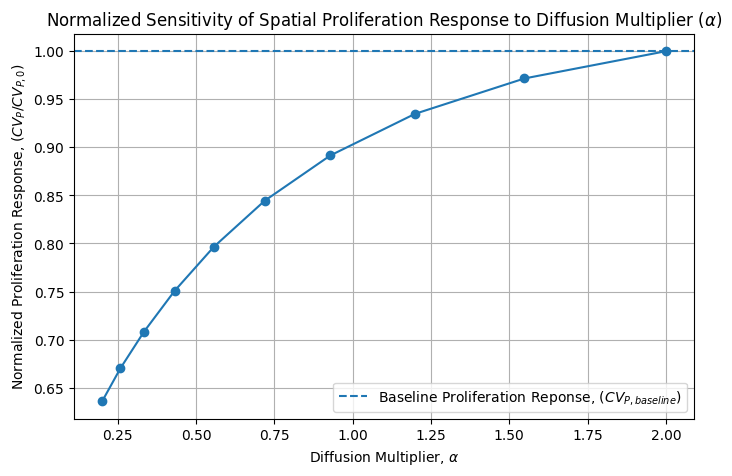

In [47]:
# Plot normalized responses (normalized to R_P_baseline)
D_responses_norm = D_responses / CV_P_baseline

plt.figure(figsize=(8, 5))

plt.plot(D_multiplier_values, D_responses_norm, marker="o")

plt.axhline(1.0, linestyle="--", label="Baseline Proliferation Reponse, (${CV}_{P, baseline}$)")

plt.xlabel(r"Diffusion Multiplier, $\alpha$")
plt.ylabel(r"Normalized Proliferation Response, (${CV}_P/{CV}_{P,0}$)")
plt.title(r"Normalized Sensitivity of Spatial Proliferation Response to Diffusion Multiplier ($\alpha$)")
plt.grid(True)

plt.legend()
plt.savefig("figures/exp05_hill_sweep")
plt.show()

In [49]:
G_1 = generate_G(1.0)

solutions_1 = run_spatial_model(

    params_baseline,

    G_1

)

P_1 = solutions_1[6]

CV_P_1 = np.std(P_1) / np.mean(P_1)

print("CV_P at D multiplier = 1:", CV_P_1)

print("Baseline CV_P:", CV_P_baseline)

print("Normalized:", CV_P_1 / CV_P_baseline)

print(

    "Max difference in G:",

    np.max(np.abs(G_1 - G))

)

print(

    "Mean difference in G:",

    np.mean(np.abs(G_1 - G))

)

print("Saved G first 5:", G[:5])

print("Generated G first 5:", G_1[:5])

print("Saved G last 5:", G[-5:])

print("Generated G last 5:", G_1[-5:])

CV_P at D multiplier = 1: 0.016823478117375425
Baseline CV_P: 0.018596703290511815
Normalized: 0.9046484129237518
Max difference in G: 0.21015801406025825
Mean difference in G: 0.07056441975375333
Saved G first 5: [1.         0.99397852 0.98795847 0.98194124 0.97592827]
Generated G first 5: [1.         0.98915523 0.97831543 0.96748558 0.95667065]
Saved G last 5: [2.19592037e-04 1.64416488e-04 1.09478898e-04 5.46998343e-05
 0.00000000e+00]
Generated G last 5: [1.08525526e-06 8.08232019e-07 5.36110584e-07 2.67243664e-07
 0.00000000e+00]
